In [4]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# ================= 配置区 =================
RAW_KG_PATH = "kg.csv"
SEED_CSV_PATH = "AIBL_Seed_DementiaHKG.csv"
OUTPUT_HKG_PATH = "AIBL_DementiaHKG_PrimeKG_Sub.csv"

def build_aibl_dementia_hkg():
    print("==================================================")
    print("🏗️ 阶段 2: 开始构建 AIBL DementiaHKG (外部精炼子图) - 引入二跳与动态剪枝...")
    
    try:
        seed_df = pd.read_csv(SEED_CSV_PATH)
        print(f"   ✅ 成功加载种子文件: {SEED_CSV_PATH}")
    except FileNotFoundError:
        print(f"   ❌ 找不到 {SEED_CSV_PATH}，请先运行第一阶段的脚本。")
        return

    # 提取有效种子节点并过滤黑名单
    valid_seeds_df = seed_df[~seed_df['AIBL_Feature'].str.contains("BLACKLIST")]
    target_nodes = set(valid_seeds_df['PrimeKG_Node'].unique())
    print(f"   🎯 激活白名单种子节点共: {len(target_nodes)} 个。")

    blacklist_types = set(seed_df[seed_df['AIBL_Feature'] == 'BLACKLIST_TYPE']['PrimeKG_Node'])
    blacklist_rels = set(seed_df[seed_df['AIBL_Feature'] == 'BLACKLIST_REL']['PrimeKG_Node'])

    print("\n   ⏳ 正在读取庞大的 PrimeKG 原始图谱，请稍候...")
    kg_df = pd.read_csv(RAW_KG_PATH, low_memory=False)

    print("\n==================================================")
    print("🚶‍♂️ 步骤 1: 提取核心 1-hop 邻居...")
    mask_1hop = (kg_df['x_name'].isin(target_nodes)) | (kg_df['y_name'].isin(target_nodes))
    subgraph_1hop = kg_df[mask_1hop].copy()

    print("\n🧼 步骤 2: 执行 1-hop 黑名单免疫清洗...")
    mask_valid_types = (~subgraph_1hop['x_type'].isin(blacklist_types)) & \
                       (~subgraph_1hop['y_type'].isin(blacklist_types))
    mask_valid_rels = ~subgraph_1hop['relation'].isin(blacklist_rels)
    clean_1hop = subgraph_1hop[mask_valid_types & mask_valid_rels].copy()
    print(f"   👉 清洗后剩余核心 1-hop 医疗边: {len(clean_1hop)} 条")

    print("\n✂️ 步骤 3: 引入 2-hop 游走并执行基于节点全局重要度的 Top-6 智能截断...")
    
    nodes_1hop = set(clean_1hop['x_name']).union(set(clean_1hop['y_name']))

    mask_2hop_x = kg_df['x_name'].isin(nodes_1hop) & (~kg_df['y_name'].isin(target_nodes))
    mask_2hop_y = kg_df['y_name'].isin(nodes_1hop) & (~kg_df['x_name'].isin(target_nodes))
    candidates_2hop = kg_df[mask_2hop_x | mask_2hop_y].copy()

    candidates_2hop = candidates_2hop[
        (~candidates_2hop['x_type'].isin(blacklist_types)) &
        (~candidates_2hop['y_type'].isin(blacklist_types)) &
        (~candidates_2hop['relation'].isin(blacklist_rels))
    ]

    candidates_2hop['source_node'] = np.where(candidates_2hop['x_name'].isin(nodes_1hop), candidates_2hop['x_name'], candidates_2hop['y_name'])
    candidates_2hop['target_node'] = np.where(candidates_2hop['x_name'].isin(nodes_1hop), candidates_2hop['y_name'], candidates_2hop['x_name'])

    print("   ⚖️ 正在计算 2-hop 节点与 AIBL 核心子图的拓扑契合度...")
    
    global_degree_x = kg_df.groupby('x_name').size()
    global_degree_y = kg_df.groupby('y_name').size()
    global_degree = global_degree_x.add(global_degree_y, fill_value=0)
    candidates_2hop['target_global_degree'] = candidates_2hop['target_node'].map(global_degree).fillna(1)
    
    local_relevance = candidates_2hop.groupby('target_node')['source_node'].nunique()
    candidates_2hop['local_relevance'] = candidates_2hop['target_node'].map(local_relevance)
    
    candidates_2hop['aibl_relevance'] = candidates_2hop['local_relevance'] / np.log1p(candidates_2hop['target_global_degree'])

    candidates_2hop = candidates_2hop.sort_values(by=['source_node', 'aibl_relevance', 'target_node'], ascending=[True, False, True])
    
    # 【修改点】ADNI是Top-5，AIBL由于初始特征少，这里修改为Top-10以弥补稀疏性
    pruned_2hop = candidates_2hop.groupby('source_node').head(6).drop(columns=['source_node', 'target_node', 'aibl_relevance', 'local_relevance', 'target_global_degree'])
    
    print(f"   👉 经过重要度排序与 Top-6 截断后，保留高质量 2-hop 扩展边: {len(pruned_2hop)} 条")

    print("\n==================================================")
    print("💾 步骤 4: 组装并导出最终图谱...")
    
    final_hkg = pd.concat([clean_1hop, pruned_2hop]).drop_duplicates()
    final_hkg.to_csv(OUTPUT_HKG_PATH, index=False, encoding='utf-8')
    
    print(f"   🎉 构建成功！最终 AIBL DementiaHKG 外部子图包含: {len(final_hkg)} 条边。")
    print(f"   📄 文件已保存至: {OUTPUT_HKG_PATH}")
    
    print("\n   [参考统计 - 节点类型分布]:")
    print(pd.concat([final_hkg['x_type'], final_hkg['y_type']]).value_counts())

if __name__ == "__main__":
    build_aibl_dementia_hkg()

🏗️ 阶段 2: 开始构建 AIBL DementiaHKG (外部精炼子图) - 引入二跳与动态剪枝...
   ✅ 成功加载种子文件: AIBL_Seed_DementiaHKG.csv
   🎯 激活白名单种子节点共: 12 个。

   ⏳ 正在读取庞大的 PrimeKG 原始图谱，请稍候...

🚶‍♂️ 步骤 1: 提取核心 1-hop 邻居...

🧼 步骤 2: 执行 1-hop 黑名单免疫清洗...
   👉 清洗后剩余核心 1-hop 医疗边: 8490 条

✂️ 步骤 3: 引入 2-hop 游走并执行基于节点全局重要度的 Top-6 智能截断...
   ⚖️ 正在计算 2-hop 节点与 AIBL 核心子图的拓扑契合度...
   👉 经过重要度排序与 Top-6 截断后，保留高质量 2-hop 扩展边: 17258 条

💾 步骤 4: 组装并导出最终图谱...
   🎉 构建成功！最终 AIBL DementiaHKG 外部子图包含: 22621 条边。
   📄 文件已保存至: AIBL_DementiaHKG_PrimeKG_Sub.csv

   [参考统计 - 节点类型分布]:
gene/protein          23059
anatomy                9513
disease                4610
biological_process     3274
effect/phenotype       2805
cellular_component      945
molecular_function      666
pathway                 370
Name: count, dtype: int64


In [5]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# 替换为你实际的AIBL诊断表路径
AIBL_CSV_PATH = "AIBL诊断.csv"

def inspect_memory_distribution():
    print("==================================================")
    print("🔍 开始探查 AIBL 数据集逻辑记忆特征分布...")
    
    try:
        df = pd.read_csv(AIBL_CSV_PATH)
        print(f"   ✅ 成功加载患者数据。")
    except FileNotFoundError:
        print(f"   ❌ 找不到文件 {AIBL_CSV_PATH}。")
        return

    # 提取正常对照组
    if 'NC' in df.columns:
        nc_df = df[df['NC'] == 1].copy()
        print(f"   📊 成功提取正常对照组 (NC) 样本共 {len(nc_df)} 例。")
    else:
        print("   ❌ 数据中未找到 'NC' 列。")
        return

    print("\n==================================================")
    print("📉 NC 组逻辑记忆分数下限分析 (数值越低代表记忆越差)：")
    
    features_to_check = ['lm_imm', 'lm_del']
    
    for col in features_to_check:
        if col in nc_df.columns:
            # 排除空值
            valid_data = nc_df[col].dropna().astype(float)
            
            if len(valid_data) > 0:
                p5 = np.percentile(valid_data, 5)
                p10 = np.percentile(valid_data, 10)
                p25 = np.percentile(valid_data, 25)
                mean_val = np.mean(valid_data)
                
                print(f"\n   ▶ 特征: {col}")
                print(f"      平均值: {mean_val:.2f}")
                print(f"      第 25 百分位数 (轻度偏低): {p25:.2f}")
                print(f"      第 10 百分位数 (异常阈值参考): {p10:.2f}")
                print(f"      第 5 百分位数 (严重偏低): {p5:.2f}")
            else:
                print(f"\n   ⚠️ NC 组的 '{col}' 列全为空值。")
        else:
            print(f"\n   ❌ 列 '{col}' 不在数据集中。")
            
    print("==================================================")

if __name__ == "__main__":
    inspect_memory_distribution()

🔍 开始探查 AIBL 数据集逻辑记忆特征分布...
   ✅ 成功加载患者数据。
   📊 成功提取正常对照组 (NC) 样本共 358 例。

📉 NC 组逻辑记忆分数下限分析 (数值越低代表记忆越差)：

   ▶ 特征: lm_imm
      平均值: 12.52
      第 25 百分位数 (轻度偏低): 10.00
      第 10 百分位数 (异常阈值参考): 8.00
      第 5 百分位数 (严重偏低): 6.00

   ▶ 特征: lm_del
      平均值: 11.07
      第 25 百分位数 (轻度偏低): 8.00
      第 10 百分位数 (异常阈值参考): 6.00
      第 5 百分位数 (严重偏低): 4.85


In [6]:
import pandas as pd
import json
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# 适配 AIBL 的文件路径
AIBL_DATA_PATH = "AIBL诊断.csv"
SEED_CSV_PATH = "AIBL_Seed_DementiaHKG.csv"
REFINED_KG_PATH = "AIBL_DementiaHKG_PrimeKG_Sub.csv"

# 请确认这两个输出文件名是否合适
OUTPUT_GRAPH_PATH = "AIBL-DementiaHKG-G.csv"
OUTPUT_DICT_PATH = "AIBL-DementiaHKG-Entities.json"

MAX_SEQ_LEN = 16 
PAD_TOKEN = "[PAD]"

def build_patient_mapping():
    print("==================================================")
    print("🔗 阶段 3: 构建患者动态映射与客观图谱格式化 (已引入序列填充与注意力掩码)...")

    try:
        kg_df = pd.read_csv(REFINED_KG_PATH)
        triplets_df = kg_df[['x_name', 'relation', 'y_name']].copy()
        triplets_df.columns = ['head', 'relation', 'tail']
        
        triplets_df.to_csv(OUTPUT_GRAPH_PATH, index=False, encoding='utf-8')
        print(f"   ✅ 标准化图谱已生成: {OUTPUT_GRAPH_PATH} (共 {len(triplets_df)} 条边)")
        print("   🔒 [安全检查]: 该图谱中不存在任何患者节点，已彻底阻断 Transductive 泄露。")
    except FileNotFoundError:
        print(f"   ❌ 找不到 {REFINED_KG_PATH}，请确保上一阶段已成功运行。")
        return

    seed_df = pd.read_csv(SEED_CSV_PATH)
    mapping_df = seed_df[seed_df['Category'] == 'Clinical_Mapping']
    aibl_to_pkg_map = dict(zip(mapping_df['AIBL_Feature'], mapping_df['PrimeKG_Node']))
    print(f"\n   📊 成功加载 {len(aibl_to_pkg_map)} 条临床特征映射规则。")

    # 提取核心种子用于优先填充
    core_seeds_df = seed_df[seed_df['Category'].str.contains('Core')]
    core_seeds = core_seeds_df['PrimeKG_Node'].tolist()

    # 替换为 AIBL 的专属阈值
    threshold_rules = {
        "mmse": lambda x: x <= 24,
        "cdr": lambda x: x >= 0.5,
        "apoe": lambda x: x >= 1,
        "lm_imm": lambda x: x <= 8,
        "lm_del": lambda x: x <= 6
    }

    try:
        aibl_df = pd.read_csv(AIBL_DATA_PATH)
    except FileNotFoundError:
        print(f"   ❌ 找不到患者数据 {AIBL_DATA_PATH}。")
        return

    patient_entities = {}
    valid_mapped_patients = 0
    total_features_mapped = 0

    print("\n   ⏳ 正在为每位患者建立固定长度的图谱实体序列与 Attention Mask...")
    
    for index, row in aibl_df.iterrows():
        if 'filename' in row and pd.notna(row['filename']):
            patient_id = str(row['filename']).strip()
        else:
            continue

        active_nodes = []
        
        for col_name, val in row.items():
            if col_name in aibl_to_pkg_map:
                if pd.notna(val) and str(val).strip().lower() not in ['', 'nan', '-4', '-1']:
                    try:
                        num_val = float(val)
                        rule = threshold_rules.get(col_name, lambda x: x > 0)
                        
                        if rule(num_val):
                            primekg_node = aibl_to_pkg_map[col_name]
                            active_nodes.append(primekg_node)
                            total_features_mapped += 1
                    except ValueError:
                        pass

        active_nodes = list(set(active_nodes))
        
        # 优先使用医学核心种子填补空白
        core_idx = 0
        while len(active_nodes) < MAX_SEQ_LEN and core_idx < len(core_seeds):
            if core_seeds[core_idx] not in active_nodes:
                active_nodes.append(core_seeds[core_idx])
            core_idx += 1

        seq_len = len(active_nodes)
        
        if seq_len > MAX_SEQ_LEN:
            active_nodes = active_nodes[:MAX_SEQ_LEN]
            attention_mask = [1] * MAX_SEQ_LEN
        else:
            pad_length = MAX_SEQ_LEN - seq_len
            attention_mask = [1] * seq_len + [0] * pad_length
            active_nodes = active_nodes + [PAD_TOKEN] * pad_length

        patient_entities[patient_id] = {
            "input_nodes": active_nodes,
            "attention_mask": attention_mask
        }
        
        if seq_len > 0:
            valid_mapped_patients += 1

    with open(OUTPUT_DICT_PATH, 'w', encoding='utf-8') as f:
        json.dump(patient_entities, f, indent=4, ensure_ascii=False)

    print("\n==================================================")
    print("💾 阶段 3 任务完成！")
    print(f"   👨‍⚕️ 处理患者总数: {len(aibl_df)}")
    print(f"   🔗 成功为 {valid_mapped_patients} 名患者提取了图谱实体。")
    print(f"   📈 总计完成特征到实体的映射: {total_features_mapped} 次。")
    print(f"   📏 序列统一长度 (MAX_SEQ_LEN): {MAX_SEQ_LEN}")
    print(f"   📄 患者动态查询字典 (包含 Mask) 已保存至: {OUTPUT_DICT_PATH}")
    print("==================================================")

if __name__ == "__main__":
    build_patient_mapping()

🔗 阶段 3: 构建患者动态映射与客观图谱格式化 (已引入序列填充与注意力掩码)...
   ✅ 标准化图谱已生成: AIBL-DementiaHKG-G.csv (共 22621 条边)
   🔒 [安全检查]: 该图谱中不存在任何患者节点，已彻底阻断 Transductive 泄露。

   📊 成功加载 5 条临床特征映射规则。

   ⏳ 正在为每位患者建立固定长度的图谱实体序列与 Attention Mask...

💾 阶段 3 任务完成！
   👨‍⚕️ 处理患者总数: 516
   🔗 成功为 516 名患者提取了图谱实体。
   📈 总计完成特征到实体的映射: 617 次。
   📏 序列统一长度 (MAX_SEQ_LEN): 16
   📄 患者动态查询字典 (包含 Mask) 已保存至: AIBL-DementiaHKG-Entities.json


In [7]:
import pandas as pd
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import warnings
import os

warnings.filterwarnings('ignore')

# ================= ⚡ 配置区 =================
GRAPH_PATH = "AIBL-DementiaHKG-G.csv"
OUTPUT_ENT2ID = "AIBL-DementiaHKG-Entity2ID.json"
OUTPUT_REL2ID = "AIBL-DementiaHKG-Relation2ID.json"
OUTPUT_EMBED = "AIBL-DementiaHKG-Embeddings.npy"
OUTPUT_LOSS_HISTORY = "AIBL-DementiaHKG-LossHistory.json" # 新增保存Loss的文件

# 超参数设置
EMBED_DIM = 128
NUM_EPOCHS = 100
BATCH_SIZE = 512
LR = 0.005
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================= 1. 统计与索引构建 =================
def analyze_graph_and_build_dicts():
    print("==================================================")
    print("📊 步骤 1: 统计图谱规模并构建 ID 映射字典...")
    
    if not os.path.exists(GRAPH_PATH):
        raise FileNotFoundError(f"❌ 找不到图谱文件: {GRAPH_PATH}")
        
    df = pd.read_csv(GRAPH_PATH)
    
    entities = sorted(list(set(df['head'].unique()) | set(df['tail'].unique())))
    relations = sorted(list(df['relation'].unique()))
    
    entity2id = {ent: idx for idx, ent in enumerate(entities)}
    relation2id = {rel: idx for idx, rel in enumerate(relations)}
    
    with open(OUTPUT_ENT2ID, 'w', encoding='utf-8') as f:
        json.dump(entity2id, f, ensure_ascii=False, indent=4)
    with open(OUTPUT_REL2ID, 'w', encoding='utf-8') as f:
        json.dump(relation2id, f, ensure_ascii=False, indent=4)
        
    print(f"   📈 [DementiaHKG 规模统计]:")
    print(f"      - 实体节点总数 (Entities): {len(entities)}")
    print(f"      - 关系类型总数 (Relations): {len(relations)}")
    print(f"      - 三元组边总数 (Triplets): {len(df)}")
    
    return df, entity2id, relation2id

# ================= 2. 数据集与模型定义 =================
class PureKGDataset(Dataset):
    def __init__(self, triplets_df, entity2id, relation2id):
        self.triplets = []
        for _, row in triplets_df.iterrows():
            h = entity2id[row['head']]
            r = relation2id[row['relation']]
            t = entity2id[row['tail']]
            self.triplets.append((h, r, t))
        self.triplets = torch.LongTensor(self.triplets)
        
    def __len__(self):
        return len(self.triplets)
    
    def __getitem__(self, idx):
        return self.triplets[idx]

class DistMult(nn.Module):
    def __init__(self, num_entities, num_relations, embed_dim):
        super(DistMult, self).__init__()
        self.num_entities = num_entities
        self.ent_emb = nn.Embedding(num_entities, embed_dim)
        self.rel_emb = nn.Embedding(num_relations, embed_dim)
        
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.xavier_uniform_(self.rel_emb.weight)
        self.criterion = nn.MarginRankingLoss(margin=1.0)

    def forward(self, h, r, t):
        h_e, r_e, t_e = self.ent_emb(h), self.rel_emb(r), self.ent_emb(t)
        return torch.sum(h_e * r_e * t_e, dim=1)

    def calculate_loss(self, h, r, t):
        batch_size = h.size(0)
        neg_t = torch.randint(0, self.num_entities, (batch_size,), device=h.device)
        pos_score = self.forward(h, r, t)
        neg_score = self.forward(h, r, neg_t)
        
        target = torch.ones(batch_size, device=h.device)
        return self.criterion(pos_score, neg_score, target)

# ================= 3. 训练主循环 =================
def train_kge():
    df, entity2id, relation2id = analyze_graph_and_build_dicts()
    
    print("\n==================================================")
    print(f"🚀 步骤 2: 启动 DistMult 模型训练 (设备: {DEVICE})...")
    
    dataset = PureKGDataset(df, entity2id, relation2id)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    model = DistMult(len(entity2id), len(relation2id), EMBED_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    
    loss_history = [] # 记录损失历史
    
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        total_loss = 0
        
        for batch in dataloader:
            batch = batch.to(DEVICE)
            h, r, t = batch[:, 0], batch[:, 1], batch[:, 2]
            
            optimizer.zero_grad()
            loss = model.calculate_loss(h, r, t)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(dataloader)
        loss_history.append(avg_loss)
        
        # 每一轮都打印 loss
        print(f"   - Epoch [{epoch:03d}/{NUM_EPOCHS}] | Train Loss: {avg_loss:.4f}")
            
    print("\n==================================================")
    print("💾 步骤 3: 提取并保存实体向量矩阵及 Loss 历史...")
    embeddings = model.ent_emb.weight.detach().cpu().numpy()
    np.save(OUTPUT_EMBED, embeddings)
    
    # 保存 Loss 到 JSON 文件中，供下一个 Cell 读取画图
    with open(OUTPUT_LOSS_HISTORY, 'w', encoding='utf-8') as f:
        json.dump(loss_history, f)
    
    print(f"   ✅ KGE 训练完成！")
    print(f"   📐 导出的向量矩阵形状: {embeddings.shape}")
    print(f"   📄 文件已保存至: {OUTPUT_EMBED} & {OUTPUT_LOSS_HISTORY}")
    print("==================================================")

if __name__ == "__main__":
    train_kge()

📊 步骤 1: 统计图谱规模并构建 ID 映射字典...
   📈 [DementiaHKG 规模统计]:
      - 实体节点总数 (Entities): 3894
      - 关系类型总数 (Relations): 18
      - 三元组边总数 (Triplets): 22621

🚀 步骤 2: 启动 DistMult 模型训练 (设备: cpu)...
   - Epoch [001/100] | Train Loss: 0.9826
   - Epoch [002/100] | Train Loss: 0.4567
   - Epoch [003/100] | Train Loss: 0.1174
   - Epoch [004/100] | Train Loss: 0.0455
   - Epoch [005/100] | Train Loss: 0.0288
   - Epoch [006/100] | Train Loss: 0.0248
   - Epoch [007/100] | Train Loss: 0.0259
   - Epoch [008/100] | Train Loss: 0.0232
   - Epoch [009/100] | Train Loss: 0.0261
   - Epoch [010/100] | Train Loss: 0.0228
   - Epoch [011/100] | Train Loss: 0.0239
   - Epoch [012/100] | Train Loss: 0.0240
   - Epoch [013/100] | Train Loss: 0.0206
   - Epoch [014/100] | Train Loss: 0.0225
   - Epoch [015/100] | Train Loss: 0.0211
   - Epoch [016/100] | Train Loss: 0.0204
   - Epoch [017/100] | Train Loss: 0.0199
   - Epoch [018/100] | Train Loss: 0.0222
   - Epoch [019/100] | Train Loss: 0.0206
   - Epoch [0

📈 步骤 4: 正在绘制 KGE 训练 Loss 收敛曲线...
   ✅ 曲线图已生成，正在当前 Cell 渲染，并已保存高清大图至: AIBL-DementiaHKG-LossCurve.png


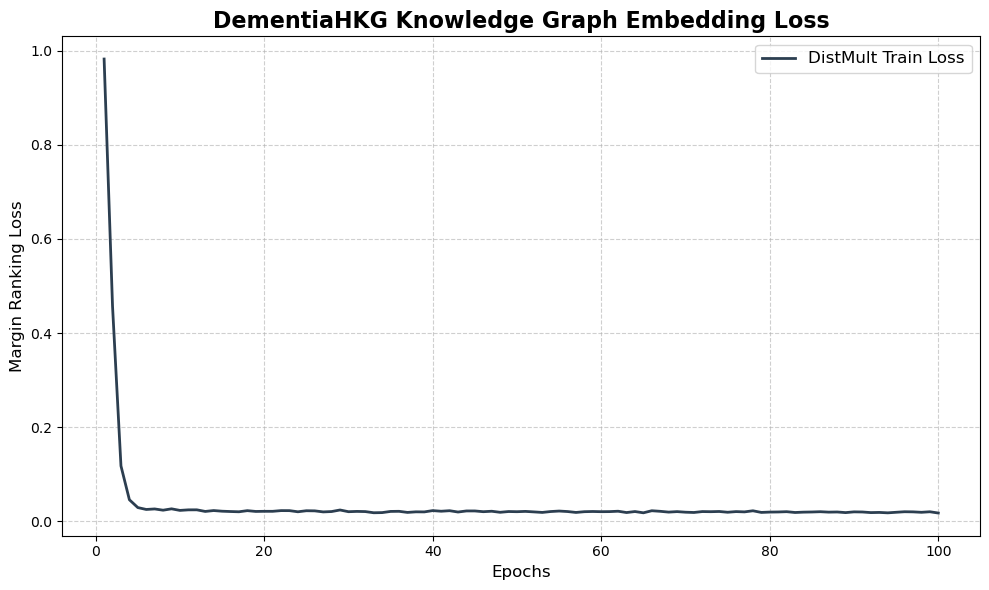

In [9]:
import matplotlib.pyplot as plt
import json
import os

# ================= 配置区 =================
LOSS_HISTORY_PATH = "AIBL-DementiaHKG-LossHistory.json"
OUTPUT_PLOT_PATH = "AIBL-DementiaHKG-LossCurve.png"

def plot_loss_curve():
    print("==================================================")
    print("📈 步骤 4: 正在绘制 KGE 训练 Loss 收敛曲线...")
    
    if not os.path.exists(LOSS_HISTORY_PATH):
        print(f"❌ 找不到 Loss 记录文件: {LOSS_HISTORY_PATH}，请确认上一步已成功训练。")
        return
        
    with open(LOSS_HISTORY_PATH, 'r', encoding='utf-8') as f:
        losses = json.load(f)
        
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(losses) + 1), losses, color='#2c3e50', linewidth=2, label='DistMult Train Loss')
    
    # 图表美化设置
    plt.title('DementiaHKG Knowledge Graph Embedding Loss', fontsize=16, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Margin Ranking Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    
    # 保存高斯清晰度的图片供论文使用
    plt.savefig(OUTPUT_PLOT_PATH, dpi=300)
    print(f"   ✅ 曲线图已生成，正在当前 Cell 渲染，并已保存高清大图至: {OUTPUT_PLOT_PATH}")
    print("==================================================")
    
    plt.show()

if __name__ == "__main__":
    plot_loss_curve()